In [ ]:
#  initialisation des dependences
import requests
import logging
import pandas as pd
import click
import pickle
import random
import datetime
import matplotlib.pyplot as plt


In [93]:
raw_data_path = 'data/2025-02-26'

with open(f'{raw_data_path}/OGD_metadata_train.pkl', 'rb') as file: 
    df_train = pickle.load(file) 
with open(f'{raw_data_path}/OGD_metadata_test.pkl', 'rb') as file: 
    df_test = pickle.load(file) 



with open(f'{raw_data_path}/Analyse_raman.pkl', 'rb') as file: 
    data_raman = pickle.load(file) 
with open(f'{raw_data_path}/Analyse_uv.pkl', 'rb') as file: 
    data_uv = pickle.load(file) 

In [98]:
# Preprocess the spectral data
from ML_un_2_preprocess_data import preprocess_spectral, preprocess
from sklearn.preprocessing import StandardScaler, OneHotEncoder

idx_train = df_train['Batch_OGD_name']
idx_test = df_test['Batch_OGD_name']
out_train, out_test, reduce_r, reduce_uv = preprocess_spectral(idx_train, idx_test, 
                                            data_raman, data_uv,
                                            mode='pca')



# Fit the kmeans and preprocess data
sc = StandardScaler()
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
X_train, sc, ohe = preprocess(df_train, sc, ohe, fit_dv=True)
X_test, _, _ = preprocess(df_test, sc, ohe, fit_dv=False)


X_train.index = idx_train
X_test.index = idx_test

data_train = pd.merge(X_train, out_train, left_index=True, right_index=True)
data_test = pd.merge(X_test, out_test, left_index=True, right_index=True)

Index(['Batch_OGD_id', 'Batch_OGD_name', 'Batch_OGD_date',
       'Batch_OGD_Technicien', 'Batch_OGD_KC8_batch', 'Batch_OGD_KC8_masse',
       'Batch_OGD_THF_batch', 'Batch_OGD_THF_Volume', 'Batch_OGD_Temperature',
       'Batch_OGD_Agitation', 'Batch_OGD_heure_debut', 'Batch_OGD_heure_fin',
       'Batch_OGD_room_HR', 'Batch_OGD_room_T', 'Batch_OGD_Stock',
       'Batch_OGD_Analyses', 'Batch_OGD_date', 'Batch_OGD_heure_debut',
       'Batch_OGD_heure_fin', 'year', 'month', 'time_exfo'],
      dtype='object')
Index(['Batch_OGD_id', 'Batch_OGD_name', 'Batch_OGD_date',
       'Batch_OGD_Technicien', 'Batch_OGD_KC8_batch', 'Batch_OGD_KC8_masse',
       'Batch_OGD_THF_batch', 'Batch_OGD_THF_Volume', 'Batch_OGD_Temperature',
       'Batch_OGD_Agitation', 'Batch_OGD_heure_debut', 'Batch_OGD_heure_fin',
       'Batch_OGD_room_HR', 'Batch_OGD_room_T', 'Batch_OGD_Stock',
       'Batch_OGD_Analyses', 'Batch_OGD_date', 'Batch_OGD_heure_debut',
       'Batch_OGD_heure_fin', 'year', 'month', 'time_

/Users/remicazelles/Documents/Travail/2023-SImplon_microsoft/PROJET_FINAL/ML_unsupervized/ML_un_2_preprocess_data.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
/Users/remicazelles/Documents/Travail/2023-SImplon_microsoft/PROJET_FINAL/ML_unsupervized/ML_un_2_preprocess_data.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
/Users/remicazelles/Docume

In [101]:
data_train

,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,TB,...,4,5,6,7,8,9,0,1,2,3
Batch_OGD_name,,,,,,,,,,,,,,,,,,,,,
OGD2217-D,0.0,0.026817,-0.148713,1.235573,0.070858,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-0.049643,0.021842,0.349437,0.031879
OGD2403-B,0.0,-1.196694,-0.148713,1.543202,0.070858,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.037920,0.026853,-0.174364,-0.204309
OGD2436-C,0.0,0.026817,-1.202698,-0.302572,-1.132085,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,-0.000632,-0.019172,0.337991,-0.004321
OGD2351-C,0.0,-1.196694,1.256601,0.312686,1.273801,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.035949,-0.015569,-0.395121,0.173130
OGD2427-D,0.0,1.250327,1.256601,1.543202,-1.132085,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.031905,0.037838,0.504891,-0.223643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OGD2336-C,0.0,1.250327,-1.202698,0.927944,-1.132085,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,-0.030675,-0.019906,-0.374223,0.092048
OGD2031-C,0.0,1.250327,-0.148713,0.005057,-1.132085,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.000361,0.030567,0.170078,0.136934
OGD2251-D,0.0,1.250327,1.256601,-1.533088,0.070858,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.003880,0.014542,0.508986,0.079830


# WORKFLOW TO PREPROCESS DATA

In [91]:
raw_data_path = 'data/2025-02-26/transformed'


with open(f'{raw_data_path}/train.pkl', 'rb') as file:
    train = pickle.load(file)
with open(f'{raw_data_path}/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [92]:
train

,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,TB,...,4,5,6,7,8,9,0,1,2,3


In [68]:
raw_data_path = 'data/2025-02-26'

with open(f'{raw_data_path}/OGD_metadata_train.pkl', 'rb') as file: 
    idx_train = pickle.load(file)['Batch_OGD_name']
with open(f'{raw_data_path}/OGD_metadata_test.pkl', 'rb') as file: 
    idx_test = pickle.load(file)['Batch_OGD_name']

with open(f'{raw_data_path}/Analyse_raman.pkl', 'rb') as file: 
    data_raman = pickle.load(file) 
with open(f'{raw_data_path}/Analyse_uv.pkl', 'rb') as file: 
    data_uv = pickle.load(file) 

In [76]:
data_raman_train = data_raman[data_raman.index.isin(idx_train)].sort_index()
data_raman_test = data_raman[data_raman.index.isin(idx_test)].sort_index()
data_uv_train = data_uv[data_uv.index.isin(idx_train)].sort_index()
data_uv_test = data_uv[data_uv.index.isin(idx_test)].sort_index()

In [77]:
from sklearn.decomposition import PCA
reduce_r = PCA(n_components=2)
data_raman_train_weights = reduce_r.fit_transform(data_raman_train)
data_raman_test_weights = reduce_r.transform(data_raman_test)
reduce_uv = PCA(n_components=2)
data_uv_train_weights = reduce_uv.fit_transform(data_uv_train)
data_uv_test_weights = reduce_uv.transform(data_uv_test)


In [89]:
pd.DataFrame(np.concatenate([data_uv_train_weights,data_raman_train_weights],axis=1),index=idx_train)
pd.DataFrame(np.concatenate([data_uv_test_weights,data_raman_test_weights],axis=1),index=idx_test)

,0,1,2,3
Batch_OGD_name,,,,
OGD2248-B,-0.049643,0.021842,0.349437,0.031879
OGD2244-C,0.037920,0.026853,-0.174364,-0.204309
OGD2136-C,-0.000632,-0.019172,0.337991,-0.004321
OGD2232-D,-0.038492,-0.006314,-0.101024,0.264247
OGD2331-C,-0.035949,-0.015569,-0.395121,0.173130
...,...,...,...,...
OGD2130-A,-0.003880,0.014542,0.508986,0.079830
OGD2419-D,0.016309,-0.025697,-0.326590,-0.214523
OGD2008-D,-0.014251,-0.015519,0.315431,0.009169


## VERIFY FUNCTION WORKS

In [57]:
from ML_un_preprocess_data import preprocess
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

sc = StandardScaler()
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
df_train, sc, ohe = preprocess(df_train, sc, ohe, fit_dv=True)
df_test, _, _ = preprocess(df_test, sc, ohe, fit_dv=False)

Index(['Batch_OGD_id', 'Batch_OGD_name', 'Batch_OGD_date',
       'Batch_OGD_Technicien', 'Batch_OGD_KC8_batch', 'Batch_OGD_KC8_masse',
       'Batch_OGD_THF_batch', 'Batch_OGD_THF_Volume', 'Batch_OGD_Temperature',
       'Batch_OGD_Agitation', 'Batch_OGD_heure_debut', 'Batch_OGD_heure_fin',
       'Batch_OGD_room_HR', 'Batch_OGD_room_T', 'Batch_OGD_Stock',
       'Batch_OGD_Analyses', 'Batch_OGD_date', 'Batch_OGD_heure_debut',
       'Batch_OGD_heure_fin', 'year', 'month', 'time_exfo'],
      dtype='object')
Index(['Batch_OGD_id', 'Batch_OGD_name', 'Batch_OGD_date',
       'Batch_OGD_Technicien', 'Batch_OGD_KC8_batch', 'Batch_OGD_KC8_masse',
       'Batch_OGD_THF_batch', 'Batch_OGD_THF_Volume', 'Batch_OGD_Temperature',
       'Batch_OGD_Agitation', 'Batch_OGD_heure_debut', 'Batch_OGD_heure_fin',
       'Batch_OGD_room_HR', 'Batch_OGD_room_T', 'Batch_OGD_Stock',
       'Batch_OGD_Analyses', 'Batch_OGD_date', 'Batch_OGD_heure_debut',
       'Batch_OGD_heure_fin', 'year', 'month', 'time_

/Users/remicazelles/Documents/Travail/2023-SImplon_microsoft/PROJET_FINAL/ML_unsupervized/ML_un_preprocess_data.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
/Users/remicazelles/Documents/Travail/2023-SImplon_microsoft/PROJET_FINAL/ML_unsupervized/ML_un_preprocess_data.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
/Users/remicazelles/Documents/

# WORKFLOW FOR SPECTRAL DATA

In [60]:
raw_data_path = 'data/2025-02-26'

with open(f'{raw_data_path}/Analyse_uv.pkl', 'rb') as file: 
    data_uv = pickle.load(file) 
with open(f'{raw_data_path}/transformed/train_.pkl', 'rb') as file:
    train_idx = pickle.load(file)
with open(f'{raw_data_path}/transformed/test_.pkl', 'rb') as file:
    test_idx = pickle.load(file)

In [61]:
train_idx

,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,TB,...,11,12,2,3,4,5,6,7,8,9
0,0.0,0.026817,-0.148713,1.235573,0.070858,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,-1.196694,-0.148713,1.543202,0.070858,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.026817,-1.202698,-0.302572,-1.132085,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,-1.196694,1.256601,0.312686,1.273801,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.250327,1.256601,1.543202,-1.132085,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,0.0,1.250327,-1.202698,0.927944,-1.132085,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
726,0.0,1.250327,-0.148713,0.005057,-1.132085,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
727,0.0,1.250327,1.256601,-1.533088,0.070858,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
728,0.0,-1.196694,1.256601,0.620315,0.070858,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
data_uv

,200,210,220,230,240,250,260,270,280,290,...,400,410,420,430,440,450,460,470,480,490
OGD2001-B,0.078015,0.090544,0.091896,0.081783,0.065528,0.051497,0.047318,0.056524,0.075991,0.095768,...,0.013003,0.013000,0.013000,0.013000,0.013000,0.013000,0.013000,0.013000,0.013000,0.013000
OGD2001-A,0.080591,0.092018,0.096074,0.092492,0.083860,0.074103,0.066437,0.062150,0.060679,0.060518,...,0.020082,0.018485,0.017443,0.016799,0.016422,0.016213,0.016102,0.016047,0.016021,0.016009
OGD2001-D,0.098135,0.100948,0.087732,0.067054,0.049831,0.042168,0.043825,0.051068,0.059664,0.066246,...,0.010776,0.010313,0.010116,0.010039,0.010012,0.010003,0.010001,0.010000,0.010000,0.010000
OGD2002-A,0.095704,0.102221,0.095904,0.081225,0.065691,0.054994,0.050660,0.051011,0.053376,0.055593,...,0.017082,0.015485,0.014443,0.013799,0.013422,0.013213,0.013102,0.013047,0.013021,0.013009
OGD2002-B,0.095196,0.106265,0.100451,0.082767,0.063674,0.051132,0.046842,0.048131,0.051459,0.054300,...,0.013426,0.011992,0.011100,0.010577,0.010287,0.010136,0.010061,0.010026,0.010011,0.010004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OGD2508-A,0.086544,0.109754,0.112963,0.095194,0.069718,0.051976,0.048547,0.056733,0.069795,0.080944,...,0.014121,0.014032,0.014007,0.014001,0.014000,0.014000,0.014000,0.014000,0.014000,0.014000
OGD2508-C,0.078809,0.093294,0.095866,0.086480,0.071409,0.059049,0.054817,0.058941,0.067615,0.075614,...,0.012257,0.012080,0.012022,0.012006,0.012001,0.012000,0.012000,0.012000,0.012000,0.012000
OGD2509-A,0.098186,0.111170,0.101707,0.077860,0.055196,0.043618,0.043270,0.049262,0.056703,0.062345,...,0.010170,0.009520,0.009214,0.009082,0.009029,0.009009,0.009003,0.009001,0.009000,0.009000
OGD2509-C,0.095614,0.092579,0.080574,0.065090,0.052539,0.047421,0.051051,0.061637,0.075051,0.086088,...,0.019121,0.019032,0.019007,0.019001,0.019000,0.019000,0.019000,0.019000,0.019000,0.019000


In [35]:
data

time_columns = ['Batch_OGD_date','Batch_OGD_heure_debut','Batch_OGD_heure_fin']
categorical_columns = ['Batch_OGD_Technicien','Batch_OGD_KC8_batch','Batch_OGD_THF_batch']
numerical_columns = ['Batch_OGD_KC8_masse','Batch_OGD_Temperature','Batch_OGD_Agitation','Batch_OGD_room_HR','Batch_OGD_room_T']

,Batch_OGD_id,Batch_OGD_name,Batch_OGD_date,Batch_OGD_Technicien,Batch_OGD_KC8_batch,Batch_OGD_KC8_masse,Batch_OGD_THF_batch,Batch_OGD_THF_Volume,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_heure_debut,Batch_OGD_heure_fin,Batch_OGD_room_HR,Batch_OGD_room_T,Batch_OGD_Stock,Batch_OGD_Analyses
0,1,OGD2001-B,2020-01-02T00:00:00,WL,K2352,20.0,Pyh7y,300,50.0,260,2020-01-02T12:00:00,2020-01-08T12:00:00,24.0,0.1,2.0,codes_analyses_separated_by_commas
1,2,OGD2001-A,2020-01-03T00:00:00,TB,K2326,20.0,eZlso,300,50.0,260,2020-01-03T12:00:00,2020-01-09T12:00:00,22.0,0.3,3.0,codes_analyses_separated_by_commas
2,4,OGD2001-D,2020-01-04T00:00:00,LB,K2446,20.0,rzipw,300,70.0,230,2020-01-04T12:00:00,2020-01-10T12:00:00,25.0,0.2,1.0,codes_analyses_separated_by_commas
3,7,OGD2002-A,2020-01-06T00:00:00,RS,K2402,20.0,3OhR0,300,60.0,260,2020-01-06T12:00:00,2020-01-12T12:00:00,28.0,0.3,3.0,codes_analyses_separated_by_commas
4,8,OGD2002-B,2020-01-06T00:00:00,LB,K2502,20.0,BywIp,400,60.0,300,2020-01-06T12:00:00,2020-01-12T12:00:00,23.0,0.1,2.0,codes_analyses_separated_by_commas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,1991,OGD2508-A,2025-02-20T00:00:00,TB,K2416,20.0,U8bBS,400,60.0,260,2025-02-20T12:00:00,2025-02-26T12:00:00,25.0,0.3,3.0,codes_analyses_separated_by_commas
908,1992,OGD2508-C,2025-02-20T00:00:00,LC,K2334,20.0,gUHh8,400,50.0,230,2025-02-20T12:00:00,2025-02-26T12:00:00,25.0,0.1,1.0,codes_analyses_separated_by_commas
909,1995,OGD2509-A,2025-02-25T00:00:00,WL,K2403,20.0,HbfS7,300,50.0,230,2025-02-25T12:00:00,2025-03-03T12:00:00,25.0,0.1,1.0,codes_analyses_separated_by_commas
910,1996,OGD2509-C,2025-02-25T00:00:00,WL,K2502,20.0,pVOcM,400,50.0,260,2025-02-25T12:00:00,2025-03-03T12:00:00,20.0,0.3,3.0,codes_analyses_separated_by_commas


In [3]:
with open('data/2025-02-25_Analyse_raman.pkl', 'rb') as file: 
    data_raman = pickle.load( file) 
with open('data/2025-02-25_Analyse_uv.pkl', 'rb') as file: 
    data_uv = pickle.load( file) 

we choose to remove strong outliers (0.9 %) for the standart scaler 


<Axes: >

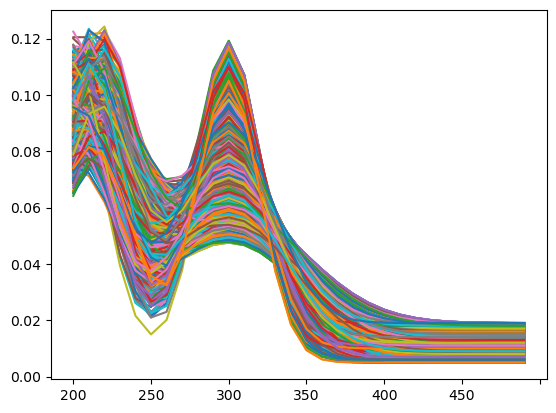

In [14]:
data_uv.T.plot(legend=False)

# GET LABEL FOR 5 CLUSTURING

In [26]:

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score


import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, SpectralClustering, AgglomerativeClustering, DBSCAN, HDBSCAN, OPTICS, Birch
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Prépare données 
X = data_uv
# Dictionnaire pour stocker les scores
scores = {}
all_labels = {}
# Fonction pour évaluer et stocker les scores
def evaluate_clustering(name, algorithm, params):
    try:
        labels = algorithm(**params).fit_predict(X)
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
        scores[name] = {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz':calinski_harabasz}
        all_labels[name] = labels
    except Exception as e:
        scores[name] = {'error': str(e)}

# Évaluation des algorithmes
evaluate_clustering('KMeans', KMeans, {'n_clusters': 2})
evaluate_clustering('SpectralClustering', SpectralClustering, {'n_clusters': 2})
evaluate_clustering('AgglomerativeClustering', AgglomerativeClustering, {'n_clusters': 2})
evaluate_clustering('GaussianMixture', GaussianMixture, {'n_components': 2})
evaluate_clustering('Birch', Birch, {'n_clusters': 2})

# Affichage des scores
scores


/Applications/anaconda3/envs/ML_Flow/lib/python3.10/site-packages/sklearn/cluster/_birch.py:725: ConvergenceWarning: Number of subclusters found (1) by BIRCH is less than (2). Decrease the threshold.
  warnings.warn(


{'KMeans': {'silhouette': np.float64(0.3179066792446285),
  'davies_bouldin': np.float64(1.2564404440424588),
  'calinski_harabasz': np.float64(518.6313298822023)},
 'SpectralClustering': {'silhouette': np.float64(0.3170448674581741),
  'davies_bouldin': np.float64(1.2568855701357105),
  'calinski_harabasz': np.float64(516.4224410494078)},
 'AgglomerativeClustering': {'silhouette': np.float64(0.2956991788351997),
  'davies_bouldin': np.float64(1.3191350957619372),
  'calinski_harabasz': np.float64(477.90514715221605)},
 'GaussianMixture': {'silhouette': np.float64(0.30894298748539895),
  'davies_bouldin': np.float64(1.2857482420450774),
  'calinski_harabasz': np.float64(494.9616816302907)},
 'Birch': {'error': 'Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)'}}

In [30]:
all_labels.keys(
)

dict_keys(['KMeans', 'SpectralClustering', 'AgglomerativeClustering', 'GaussianMixture'])

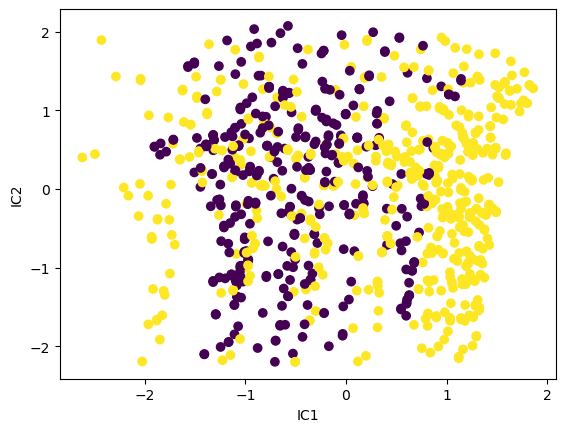

In [ ]:
from sklearn.decomposition import FastICA
from sklearn.manifold import TSNE

pca = PCA 
transformer = FastICA(n_components=2,
        random_state=0,
        whiten='unit-variance')

X_transformed = transformer.fit_transform(data_uv)

plt.scatter(X_transformed[:,0], X_transformed[:,1], c=all_labels['GaussianMixture'])
plt.xlabel('IC1')
plt.ylabel('IC2')
plt.show()  